In [1]:
!pip install -q keras-tuner


In [2]:
import json
import requests
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt
import keras_tuner as kt

In [3]:
# --- Load Dataset ---
url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/06.%20Week%206/Datasets/DeteksiSarkasme.json"
data = [json.loads(line) for line in requests.get(url).text.strip().split("\n")]
sentences = [item['headline'].lower() for item in data]
labels = np.array([item['is_sarcastic'] for item in data])

In [4]:
# --- Tokenization ---
tok = Tokenizer(oov_token="<OOV>")
tok.fit_on_texts(sentences)
sequences = tok.texts_to_sequences(sentences)
vocab_size = len(tok.word_index) + 1
X = pad_sequences(sequences, maxlen=40, padding='post')

In [5]:
# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

In [6]:
# --- Model Builder ---
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=hp.Choice('embed_dim', [64, 128, 200]), input_length=40))
    model.add(tf.keras.layers.GRU(units=hp.Choice('gru_units', [64, 128, 256]), return_sequences=False))
    model.add(tf.keras.layers.Dropout(hp.Float('dropout', 0.3, 0.5, step=0.1)))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('lr', [1e-3, 3e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [12]:
# --- Hyperparameter Tuning ---
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     directory='keras_tuner',
                     project_name='gru_sarcasm')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
tuner.search(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=64)

Reloading Tuner from keras_tuner/gru_sarcasm/tuner0.json
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


268/268 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5635 - loss: 0.6867 - val_accuracy: 0.5538 - val_loss: 0.6893
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5545 - loss: 0.6884 - val_accuracy: 0.5538 - val_loss: 0.6878
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5600 - loss: 0.6867 - val_accuracy: 0.5538 - val_loss: 0.6881
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5655 - loss: 0.6853 - val_accuracy: 0.5538 - val_loss: 0.6873
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5688 - loss: 0.6841 - val_accuracy: 0.5538 - val_loss: 0.6874
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5587 - loss: 0.6866 - val_accuracy: 0.5538 - val_loss: 0.6890
Epoch 7/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5614 - loss: 0.6869 - val_accuracy: 0.5538 - val_loss: 0.6878
Epoch 8/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5906 - loss: 0.6645 - val_accuracy: 0.7190

In [13]:
# --- Evaluate ---
train_preds = (model.predict(X_train).ravel() > 0.5).astype(int)
test_probs = model.predict(X_test).ravel()
test_preds = (test_probs > 0.5).astype(int)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec = recall_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)
auc = roc_auc_score(y_test, test_probs)

print(f"\n📌 Best Hyperparameters: {best_hps.values}")
print(f"✅ Final Training Accuracy: {train_acc*100:.2f}%")
print(f"✅ Final Testing Accuracy: {test_acc*100:.2f}%")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"AUC: {auc:.2f}")

668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📌 Best Hyperparameters: {'embed_dim': 128, 'gru_units': 256, 'dropout': 0.3, 'lr': 0.001, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}
✅ Final Training Accuracy: 96.38%
✅ Final Testing Accuracy: 81.80%
Precision: 0.80
Recall: 0.78
F1 Score: 0.79
AUC: 0.87


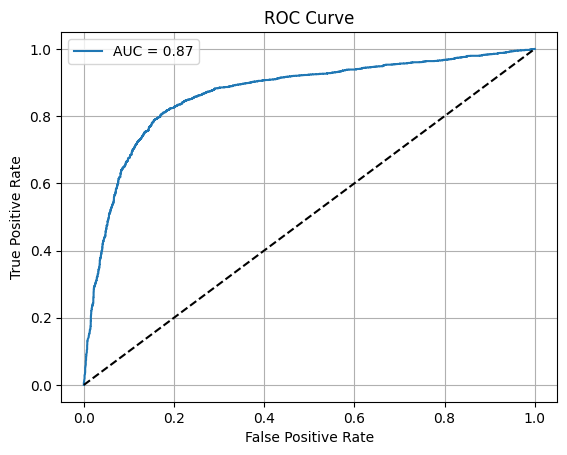

In [14]:
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

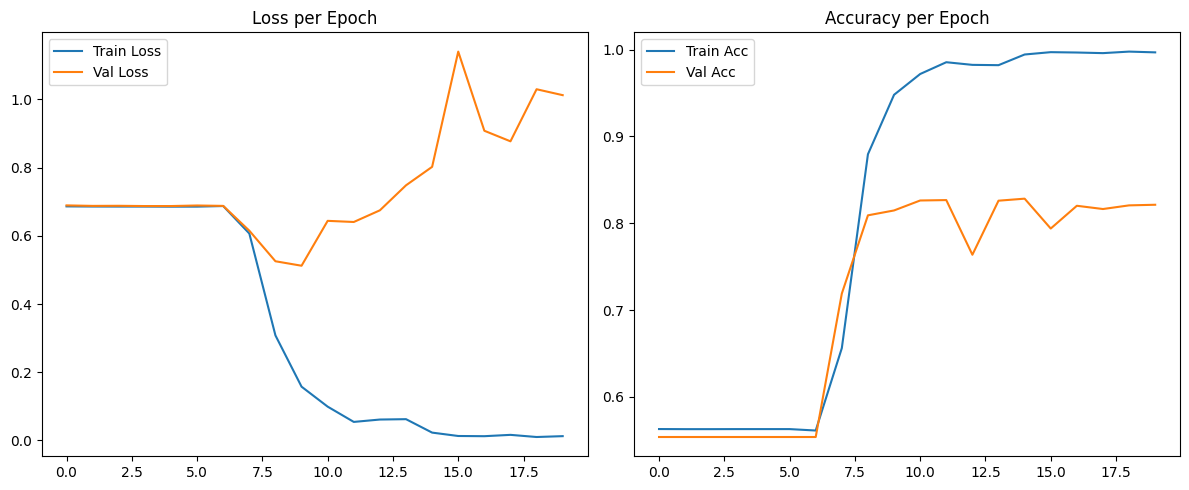

In [15]:
# --- Loss & Accuracy Plot ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss per Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy per Epoch")
plt.legend()

plt.tight_layout()
plt.show()

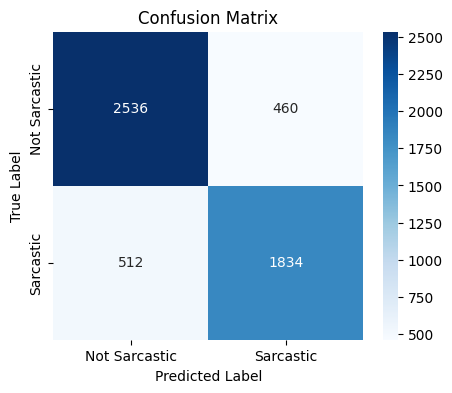

In [17]:
# --- Confusion Matrix ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Sarcastic", "Sarcastic"], yticklabels=["Not Sarcastic", "Sarcastic"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
